In [ ]:
# Melakukan import file/data yang digunakan ke dalam google colab
# from google.colab import files
# uploaded = files.upload()

Saving data.csv to data.csv


In [1]:
#y Melakukan instalasi library Pyspark
# !pip install pyspark

# Melakukan import data library yang digunakan u
import psutil
import pyspark
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# print(psutil.cpu_percent())

In [ ]:
# Melakukan inisialisasi SparkSession
spark = SparkSession.builder.appName("Earthquakes In Indonesia").getOrCreate()

# print(psutil.cpu_percent())

47.9


In [3]:
# Melakukan inisialisasi file yang digunakan berdasarkan data file yang diunggah
csv_file = 'katalog_gempa.csv'

# Membaca file CSV yang digunakan
df = spark.read.csv(csv_file, header=True, inferSchema=True)

# Tampilkan skema DataFrame dan beberapa baris data (20 data teratas)
df.printSchema()
df.show()

# print(psutil.cpu_percent())

root
 |-- tgl: string (nullable = true)
 |-- ot: timestamp (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- depth: integer (nullable = true)
 |-- mag: double (nullable = true)
 |-- remark: string (nullable = true)
 |-- strike1: double (nullable = true)
 |-- dip1: double (nullable = true)
 |-- rake1: double (nullable = true)
 |-- strike2: double (nullable = true)
 |-- dip2: double (nullable = true)
 |-- rake2: double (nullable = true)

+----------+--------------------+-----+------+-----+---+--------------------+-------+----+-----+-------+----+-----+
|       tgl|                  ot|  lat|   lon|depth|mag|              remark|strike1|dip1|rake1|strike2|dip2|rake2|
+----------+--------------------+-----+------+-----+---+--------------------+-------+----+-----+-------+----+-----+
|2008/11/01|2026-09-10 21:02:...|-9.18|119.06|   10|4.9|Sumba Region - In...|   NULL|NULL| NULL|   NULL|NULL| NULL|
|2008/11/01|2026-09-10 20:58:...|-6.55|129.64|   10|4

In [4]:
# Memilih dan menginisialisasi kolom 'tgl' hingga 'remark' untuk ditampilkan (kolom data yang digunakan)
selected_cols = ['tgl', 'ot', 'lat', 'lon', 'depth', 'mag', 'remark']
df_selected = df.select(*selected_cols)
df_selected.show()

# print(psutil.cpu_percent())

+----------+--------------------+-----+------+-----+---+--------------------+
|       tgl|                  ot|  lat|   lon|depth|mag|              remark|
+----------+--------------------+-----+------+-----+---+--------------------+
|2008/11/01|2026-09-10 21:02:...|-9.18|119.06|   10|4.9|Sumba Region - In...|
|2008/11/01|2026-09-10 20:58:...|-6.55|129.64|   10|4.6|           Banda Sea|
|2008/11/01|2026-09-10 17:43:...|-7.01|106.63|  121|3.7|    Java - Indonesia|
|2008/11/01|2026-09-10 16:24:...| -3.3|127.85|   10|3.2|   Seram - Indonesia|
|2008/11/01|2026-09-10 16:20:...|-6.41|129.54|   70|4.3|           Banda Sea|
|2008/11/01|2026-09-10 14:47:...|-7.37|105.31|   18|3.3|    Java - Indonesia|
|2008/11/01|2026-09-10 13:04:...|  0.1| 98.55|   12|4.7|Northern Sumatra ...|
|2008/11/01|2026-09-10 10:23:...|-7.07|129.67|  135|4.8|           Banda Sea|
|2008/11/01|2026-09-10 09:50:...|-3.32|128.02|   10|2.3|   Seram - Indonesia|
|2008/11/01|2026-09-10 06:50:...|-4.43|127.45|   10|3.2|        

In [5]:
# Melakukan summary dan mengubah hasilnya menjadi Pandas DataFrame
df_selected.summary().toPandas()

# print(psutil.cpu_percent())

,summary,tgl,lat,lon,depth,mag,remark
0,count,92887,92887,92887,92887,92887,92887
1,mean,None,-3.4045773897316254,119.15970674044851,49.00939851647701,3.5927880112394885,None
2,stddev,None,4.354583888965942,10.83320192607037,76.76106992751242,0.8340422367811201,None
3,min,2008/11/01,-11.0,94.02,2,1.0,Arafura Sea
4,25%,None,-7.89,113.16,10,3.0,None
5,50%,None,-2.91,121.16,16,3.5,None
6,75%,None,0.14,126.9,54,4.2,None
7,max,2023/01/26,6.0,142.0,750,7.9,W. Caroline Islands - Micronesia


In [6]:
# Menggantikan sebuah tampilan (view) sementara dengan nama "EarthquakesData"
df_selected.createOrReplaceTempView("EarthquakesData")

# print(psutil.cpu_percent())

In [7]:
# Melakukan query untuk mencari magnitude gempa terbanyak yang terjadi dalam data
query_most_frequent = """
SELECT mag, COUNT(*) as count
FROM EarthquakesData
GROUP BY mag
ORDER BY count DESC
LIMIT 1
"""

# Mengeksekusi query yang dibuat dengan spark
result_most_frequent = spark.sql(query_most_frequent)
most_frequent_magnitude_df = result_most_frequent.toPandas()
print("Most Frequent Magnitude:")
print(most_frequent_magnitude_df)

# Melakukan query untuk mencari magnitude gempa paling sedikit yang terjadi dalam data
query_lest_frequent = """
SELECT mag, COUNT(*) as count
FROM EarthquakesData
GROUP BY mag
ORDER BY count ASC
LIMIT 1
"""

# Mengeksekusi query yang dibuat dengan spark
result_lest_frequent = spark.sql(query_lest_frequent)
lest_frequent_magnitude_df = result_lest_frequent.toPandas()
print("Lest Frequent Magnitude:")
print(lest_frequent_magnitude_df)

# print(psutil.cpu_percent())

Most Frequent Magnitude:
   mag  count
0  3.3   4530
Lest Frequent Magnitude:
   mag  count
0  7.9      1


In [8]:
# Menjalankan query SQL untuk mencari berapa banyak data dengan magnitode di atas 5.0
magupfive = spark.sql("SELECT * FROM EarthquakesData WHERE mag>=5.0")

# Mengonversi dan menampilkan hasil query menjadi Pandas DataFrame
magupfive.toPandas()

,tgl,ot,lat,lon,depth,mag,remark
0,2008/11/01,2026-09-10 01:34:29.660,-6.61,129.39,30,5.5,Banda Sea
1,2008/11/03,2026-09-10 19:22:03.486,1.10,97.34,39,5.5,Northern Sumatra - Indonesia
2,2008/11/06,2026-09-10 18:37:12.230,-2.37,99.82,58,5.0,Southern Sumatra - Indonesia
3,2008/11/07,2026-09-10 16:04:27.451,-6.76,129.37,39,6.2,Banda Sea
4,2008/11/07,2026-09-10 09:18:10.776,-7.24,127.97,30,5.0,Banda Sea
...,...,...,...,...,...,...,...
5071,2023/01/24,2026-09-10 02:13:19.875,2.84,127.04,52,5.9,Northern Molucca Sea
5072,2023/01/24,2026-09-10 01:10:25.606,2.81,127.03,10,5.0,Northern Molucca Sea
5073,2023/01/24,2026-09-10 01:10:25.606,2.81,127.03,10,5.0,Northern Molucca Sea
5074,2023/01/26,2026-09-10 04:23:50.693,3.09,127.08,10,5.7,Talaud Islands - Indonesia


In [9]:
# Menghitung banyak gempa dari data sebelumnya di tiap magnitude yang berbeda
query = """
SELECT mag, COUNT(*) as count
FROM EarthquakesData
WHERE remark LIKE '%Sumbawa Region%' AND mag >= 5.0
GROUP BY mag
ORDER BY mag ASC
"""

# Menjalankan query SQL dan menampilkan tabelnya
result = spark.sql(query)
all_rows = result.collect()
for row in all_rows:
    print(row)

print(psutil.cpu_percent())

Row(mag=5.0, count=37)
Row(mag=5.1, count=30)
Row(mag=5.2, count=27)
Row(mag=5.3, count=7)
Row(mag=5.4, count=10)
Row(mag=5.5, count=6)
Row(mag=5.6, count=5)
Row(mag=5.7, count=2)
Row(mag=5.8, count=2)
Row(mag=6.2, count=4)
Row(mag=6.3, count=1)
Row(mag=6.4, count=2)
Row(mag=6.5, count=2)
Row(mag=6.7, count=1)
Row(mag=6.8, count=2)
Row(mag=6.9, count=2)
Row(mag=7.0, count=1)
35.4


In [10]:
# Menjalankan query SQL untuk mencari berapa banyak data dengan magnitode di bawah 5.0
magminfive = spark.sql("SELECT * FROM EarthquakesData WHERE remark LIKE '%Sumbawa Region%' AND mag <= 5.0")

# Mengonversi dan menampilkan hasil query menjadi Pandas DataFrame
magminfive.toPandas()

,tgl,ot,lat,lon,depth,mag,remark
0,2008/11/03,2026-09-10 07:42:58.943,-8.91,117.31,131,4.3,Sumbawa Region - Indonesia
1,2008/11/08,2026-09-10 11:24:33.197,-8.16,118.78,8,3.9,Sumbawa Region - Indonesia
2,2008/11/10,2026-09-10 11:43:19.606,-8.15,117.83,41,4.4,Sumbawa Region - Indonesia
3,2008/11/29,2026-09-10 02:52:58.271,-8.85,116.94,5,3.9,Sumbawa Region - Indonesia
4,2008/12/15,2026-09-10 23:07:40.108,-8.27,116.02,154,3.5,Sumbawa Region - Indonesia
...,...,...,...,...,...,...,...
7203,2023/01/26,2026-09-10 12:13:39.697,-8.31,117.55,195,3.7,Sumbawa Region - Indonesia
7204,2023/01/26,2026-09-10 08:00:12.749,-8.79,118.87,10,2.3,Sumbawa Region - Indonesia
7205,2023/01/26,2026-09-10 06:35:39.047,-9.05,116.53,19,2.7,Sumbawa Region - Indonesia
7206,2023/01/26,2026-09-10 04:56:26.743,-8.04,118.89,97,3.0,Sumbawa Region - Indonesia


In [11]:
# Menjalankan query SQL untuk mencari magnitudo gempa yang paling sering terjadi di Sumbawa
query = """
SELECT mag, COUNT(*) as count
FROM EarthquakesData
WHERE remark LIKE '%Sumbawa Region%'
GROUP BY mag
ORDER BY count DESC
LIMIT 1
"""

# Mengonversi, menjalankan, menampilkan hasil query menjadi Pandas DataFrame
result = spark.sql(query)
most_frequent_magnitude_df = result.toPandas()
print(most_frequent_magnitude_df)

# Menjalankan query SQL untuk mencari magnitudo gempa yang paling jarang terjadi di Sumbawa
query = """
SELECT mag, COUNT(*) as count
FROM EarthquakesData
WHERE remark LIKE '%Sumbawa Region%'
GROUP BY mag
ORDER BY count ASC
LIMIT 1
"""

# Mengonversi, menjalankan, menampilkan hasil query menjadi Pandas DataFrame
result = spark.sql(query)
least_frequent_magnitude_df = result.toPandas()
print(least_frequent_magnitude_df)

print(psutil.cpu_percent())

   mag  count
0  2.7    445
   mag  count
0  7.0      1
41.3


In [12]:
# Menghitung banyak gempa dari data sebelumnya di tiap magnitude yang berbeda
query = """
SELECT mag, COUNT(*) as count
FROM EarthquakesData
WHERE remark LIKE '%Sumbawa Region%' AND mag <= 5.0
GROUP BY mag
ORDER BY mag ASC
"""

# Menjalankan query SQL dan menampilkan tabelnya
result = spark.sql(query)
all_rows = result.collect()
for row in all_rows:
    print(row)

print(psutil.cpu_percent())

Row(mag=1.1, count=1)
Row(mag=1.3, count=1)
Row(mag=1.5, count=7)
Row(mag=1.6, count=12)
Row(mag=1.7, count=20)
Row(mag=1.8, count=32)
Row(mag=1.9, count=52)
Row(mag=2.0, count=94)
Row(mag=2.1, count=160)
Row(mag=2.2, count=214)
Row(mag=2.3, count=273)
Row(mag=2.4, count=327)
Row(mag=2.5, count=371)
Row(mag=2.6, count=410)
Row(mag=2.7, count=445)
Row(mag=2.8, count=396)
Row(mag=2.9, count=418)
Row(mag=3.0, count=405)
Row(mag=3.1, count=391)
Row(mag=3.2, count=350)
Row(mag=3.3, count=343)
Row(mag=3.4, count=347)
Row(mag=3.5, count=280)
Row(mag=3.6, count=261)
Row(mag=3.7, count=234)
Row(mag=3.8, count=195)
Row(mag=3.9, count=183)
Row(mag=4.0, count=158)
Row(mag=4.1, count=161)
Row(mag=4.2, count=106)
Row(mag=4.3, count=99)
Row(mag=4.4, count=94)
Row(mag=4.5, count=90)
Row(mag=4.6, count=64)
Row(mag=4.7, count=67)
Row(mag=4.8, count=61)
Row(mag=4.9, count=49)
Row(mag=5.0, count=37)
38.4


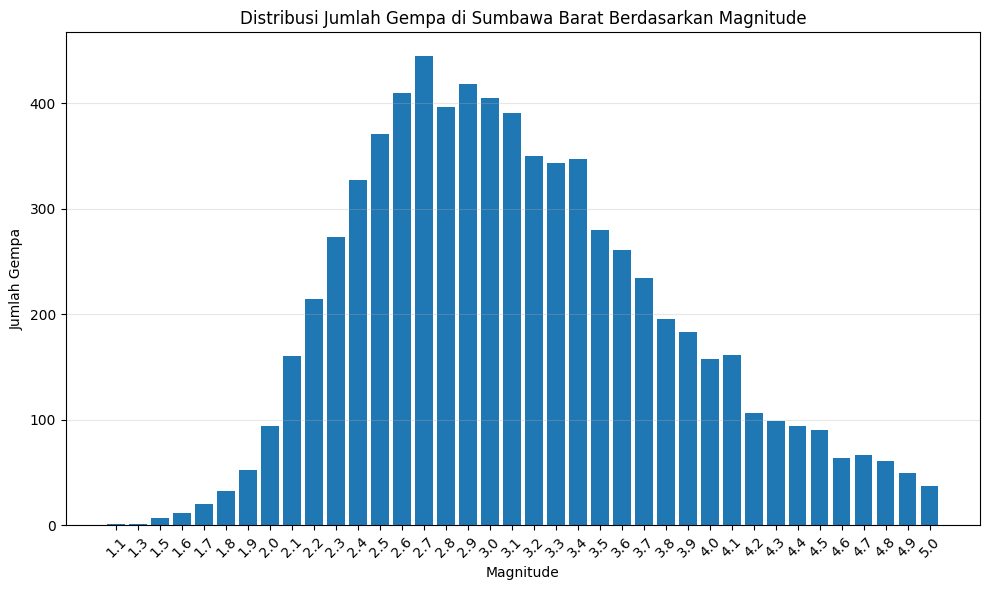

In [18]:
# ------------------------------------------------------------
# VISUALISASI 1
# Distribusi Jumlah Gempa Berdasarkan Magnitude
# ------------------------------------------------------------

query_visual_1 = """
SELECT mag, COUNT(*) AS jumlah_gempa
FROM EarthquakesData
WHERE remark LIKE '%Sumbawa Region%' AND mag <= 5.0
GROUP BY mag
ORDER BY mag ASC
"""

result_visual_1 = spark.sql(query_visual_1)

# Mengubah hasil Spark menjadi Pandas DataFrame
visual_1_df = result_visual_1.toPandas()

# Membuat bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    visual_1_df['mag'].astype(str),
    visual_1_df['jumlah_gempa']
)

plt.title('Distribusi Jumlah Gempa di Sumbawa Barat Berdasarkan Magnitude')
plt.xlabel('Magnitude')
plt.ylabel('Jumlah Gempa')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

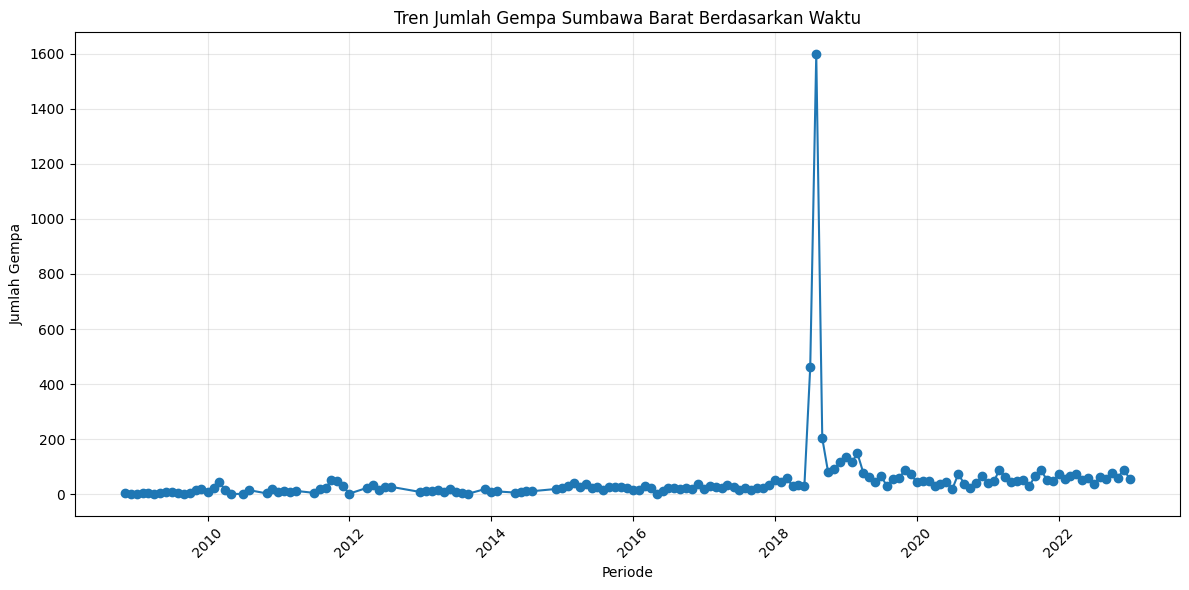

In [28]:
# ------------------------------------------------------------
# VISUALISASI 2
# Jumlah Gempa Berdasarkan Waktu
# ------------------------------------------------------------

query_visual_2 = """
SELECT tgl, COUNT(*) AS jumlah_gempa
FROM EarthquakesData
WHERE remark LIKE '%Sumbawa Region%'
GROUP BY tgl
ORDER BY tgl ASC
"""

result_visual_2 = spark.sql(query_visual_2)

# Mengubah hasil Spark menjadi Pandas DataFrame
visual_2_df = result_visual_2.toPandas()

# Mengubah kolom tanggal menjadi format datetime
visual_2_df['tgl'] = pd.to_datetime(
    visual_2_df['tgl'],
    errors='coerce'
)

# Menghapus data tanggal yang tidak berhasil dibaca
visual_2_df = visual_2_df.dropna(subset=['tgl'])

# Mengelompokkan data berdasarkan bulan
visual_2_df['bulan'] = visual_2_df['tgl'].dt.to_period('M')

monthly_earthquake = (
    visual_2_df
    .groupby('bulan')['jumlah_gempa']
    .sum()
    .reset_index()
)

# Mengubah periode menjadi datetime
monthly_earthquake['bulan'] = (
    monthly_earthquake['bulan'].dt.to_timestamp()
)

# Membuat line chart
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_earthquake['bulan'],
    monthly_earthquake['jumlah_gempa'],
    marker='o'
)

plt.title('Tren Jumlah Gempa Sumbawa Barat Berdasarkan Waktu')
plt.xlabel('Periode')
plt.ylabel('Jumlah Gempa')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

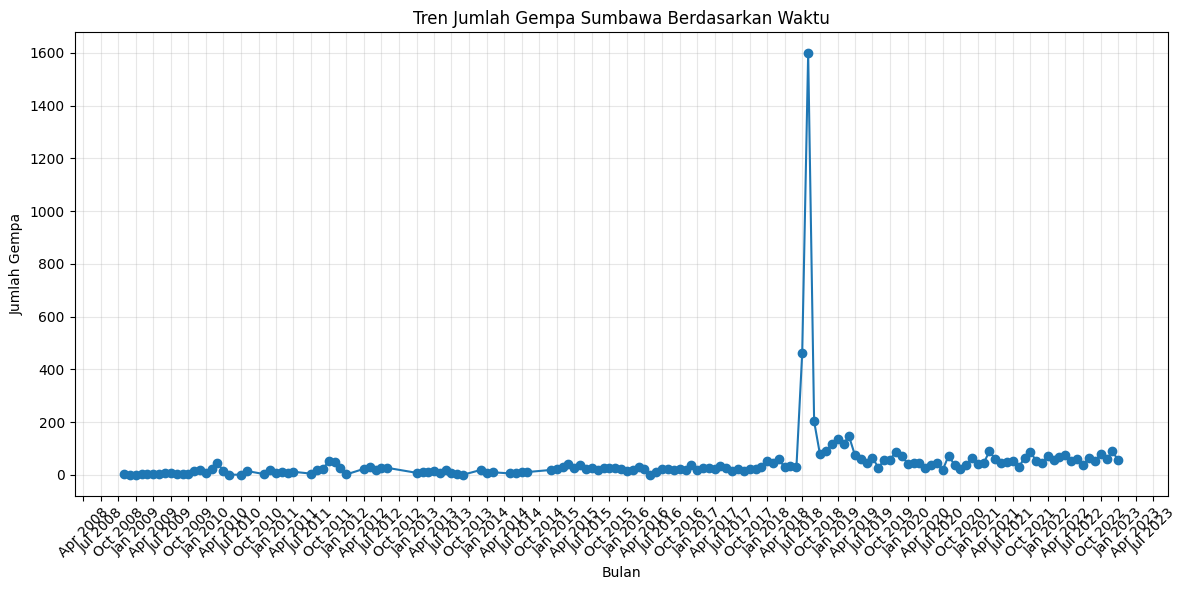

In [29]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_earthquake['bulan'],
    monthly_earthquake['jumlah_gempa'],
    marker='o'
)

plt.title('Tren Jumlah Gempa Sumbawa Berdasarkan Waktu')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Gempa')

# Format sumbu X menjadi Bulan-Tahun
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

# Menampilkan label setiap 3 bulan
plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
query_visual_2 = """
SELECT
    date_format(to_date(tgl, 'yyyy/MM/dd'), 'yyyy-MM') AS bulan,
    COUNT(*) AS jumlah_gempa
FROM EarthquakesData
WHERE remark LIKE '%Sumbawa Region%'
AND YEAR(to_date(tgl, 'yyyy/MM/dd')) BETWEEN 2020 AND 2024
GROUP BY date_format(to_date(tgl, 'yyyy/MM/dd'), 'yyyy-MM')
ORDER BY bulan ASC
"""

result_visual_2 = spark.sql(query_visual_2)

visual_2_df = result_visual_2.toPandas()

visual_2_df['bulan'] = pd.to_datetime(
    visual_2_df['bulan'],
    format='%Y-%m'
)

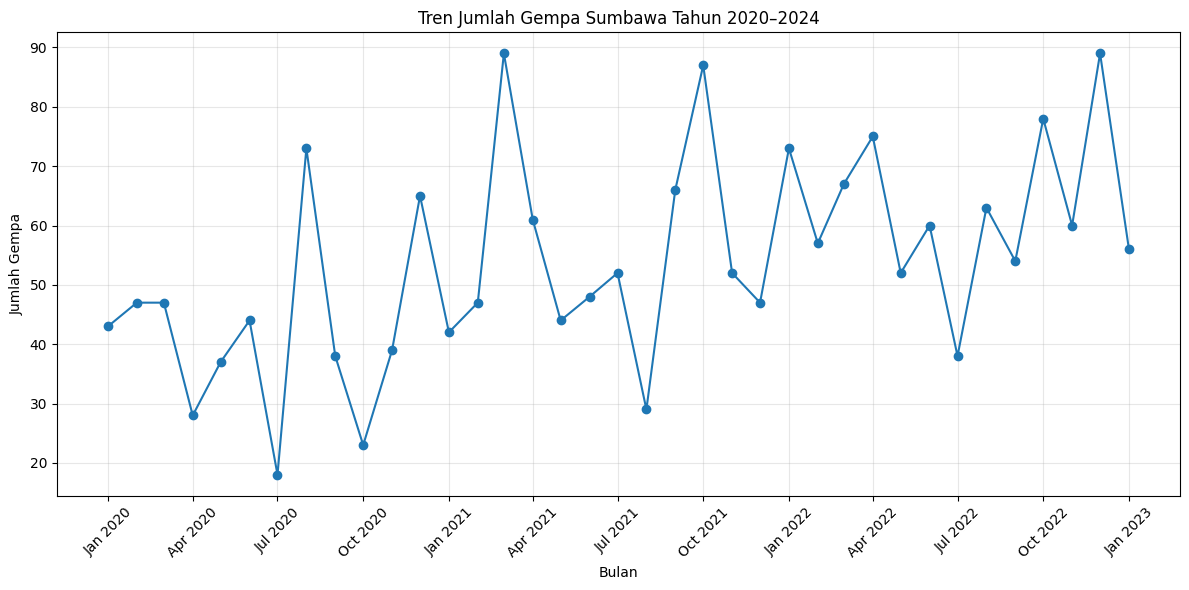

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(
    visual_2_df['bulan'],
    visual_2_df['jumlah_gempa'],
    marker='o'
)

plt.title('Tren Jumlah Gempa Sumbawa Tahun 2020–2024')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Gempa')

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

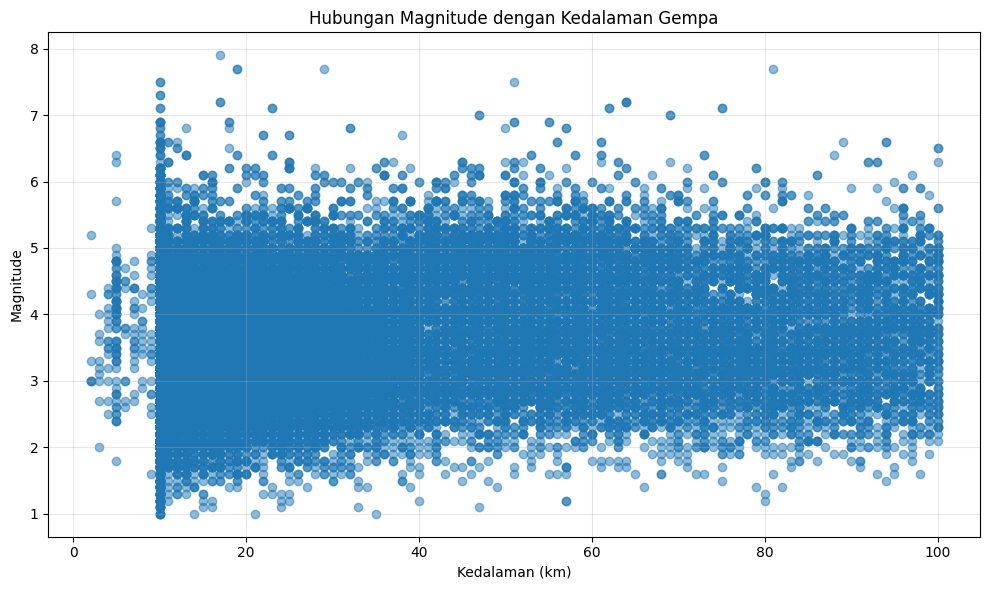

In [37]:
# ------------------------------------------------------------
# VISUALISASI 3
# Hubungan Magnitude dengan Kedalaman Gempa
# ------------------------------------------------------------

query_visual_3 = """
SELECT mag, depth
FROM EarthquakesData
WHERE mag IS NOT NULL
AND depth <= 100
"""

result_visual_3 = spark.sql(query_visual_3)

# Mengubah hasil Spark menjadi Pandas DataFrame
visual_3_df = result_visual_3.toPandas()

# Membuat scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    visual_3_df['depth'],
    visual_3_df['mag'],
    alpha=0.5
)

plt.title('Hubungan Magnitude dengan Kedalaman Gempa')
plt.xlabel('Kedalaman (km)')
plt.ylabel('Magnitude')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()